Dataset Overview
-

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
github_link = "https://raw.githubusercontent.com/Buket12345/climbing-ifsc-dsa210/main"
import pandas as pd

df = pd.read_csv(f"{github_link}/final_dataset.csv")
print(df.shape)
df.head()

(126441, 18)


,athlete_id,rank,discipline,season,date,event_id,event_location,d_cat,firstname,lastname,age,gender,country,height,arm_span,paraclimbing_sport_class,birthday,gdp_per_capita
0,14,1,lead,2022,2022-07-09,1280,Villars,585,Korbinian,FRANCK,35.0,male,DEU,NaN,NaN,"Limited Range, Power & Stability 1: RP1",1989-09-02,63353.940
1,14,1,lead,2022,2022-06-22,1277,Innsbruck,585,Korbinian,FRANCK,35.0,male,DEU,NaN,NaN,"Limited Range, Power & Stability 1: RP1",1989-09-02,63353.940
2,14,1,lead,2022,2022-05-26,1278,Salt Lake City,585,Korbinian,FRANCK,35.0,male,DEU,NaN,NaN,"Limited Range, Power & Stability 1: RP1",1989-09-02,63353.940
3,14,2,lead,2021,2021-10-11,1224,United States,585,Korbinian,FRANCK,35.0,male,DEU,NaN,NaN,"Limited Range, Power & Stability 1: RP1",1989-09-02,62950.047
4,14,3,lead,2021,2021-09-17,1225,Moscow,585,Korbinian,FRANCK,35.0,male,DEU,NaN,NaN,"Limited Range, Power & Stability 1: RP1",1989-09-02,62950.047


In [2]:
df.info()

df[['rank', 'gdp_per_capita', 'age', 'height']].describe()

print("Number of unique countries:", df['country'].nunique())
print("Season range:", df['season'].min(), "-", df['season'].max())
print("Disciplines:", df['discipline'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126441 entries, 0 to 126440
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   athlete_id                126441 non-null  int64  
 1   rank                      126441 non-null  int64  
 2   discipline                126441 non-null  object 
 3   season                    126441 non-null  int64  
 4   date                      126441 non-null  object 
 5   event_id                  126441 non-null  int64  
 6   event_location            125684 non-null  object 
 7   d_cat                     126441 non-null  int64  
 8   firstname                 126441 non-null  object 
 9   lastname                  126441 non-null  object 
 10  age                       84796 non-null   float64
 11  gender                    126441 non-null  object 
 12  country                   126441 non-null  object 
 13  height                    23695 non-null   f

Plotting Useful Graphs for Visualisation
----

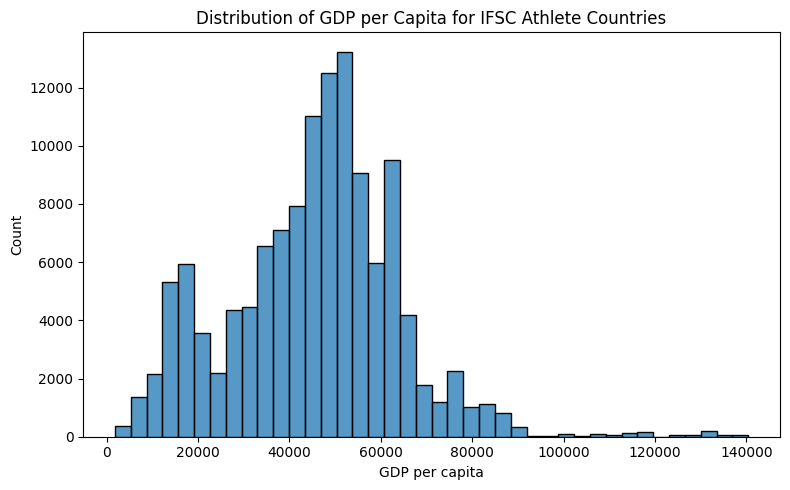

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['gdp_per_capita'], bins=40)
plt.xlabel("GDP per capita")
plt.title("Distribution of GDP per Capita for IFSC Athlete Countries")
plt.tight_layout()
plt.show()

We see that the GDP distribution is right skewed. This means the data have economic diversity. While most IFSC athletes come from mid-to-high income countries, a handful come from extremely high-GDP countries

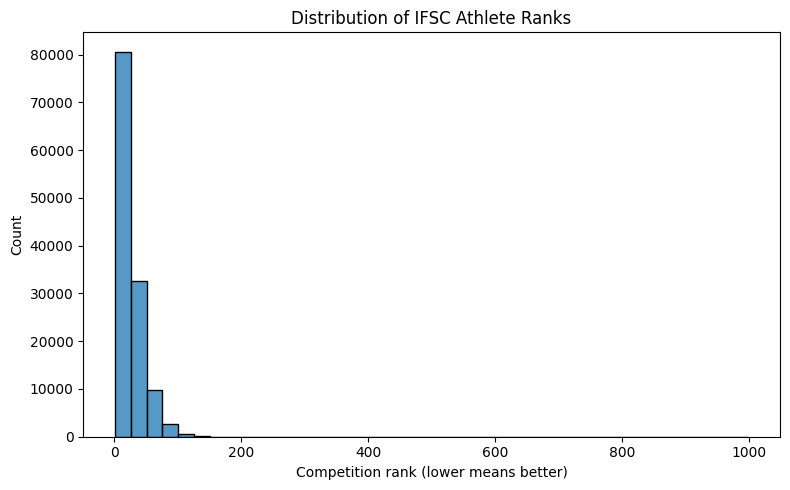

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['rank'], bins=40)
plt.xlabel("Competition rank (lower means better)")
plt.title("Distribution of IFSC Athlete Ranks")
plt.tight_layout()
plt.show()

This is how the performance of athletes look like in IFSC data. Almost nothing appears beyond 200 which shows we are dealing with high performing athletes.

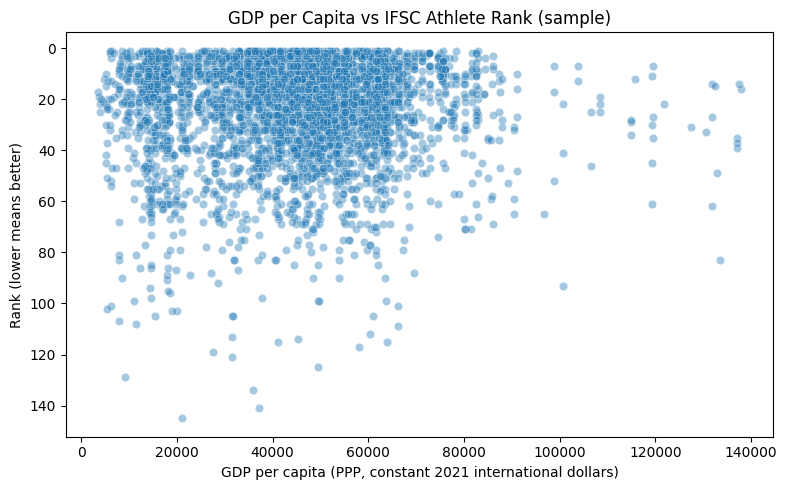

In [5]:
sample_df = df.sample(4000, random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df, x='gdp_per_capita', y='rank', alpha=0.4)
plt.gca().invert_yaxis()   #so that better ranks appear higher
plt.xlabel("GDP per capita (PPP, constant 2021 international dollars)")
plt.ylabel("Rank (lower means better)")
plt.title("GDP per Capita vs IFSC Athlete Rank (sample)")
plt.tight_layout()
plt.show()

This is the raw data plotted with scatter plot to visualise. The plot visually confirms that extremely low or extremely high GDP countries tend to show different patterns.

In [6]:
country_season = (
    df.groupby(['country', 'season'], as_index=False)
      .agg(
          mean_rank=('rank', 'mean'),
          events=('rank', 'size'),
          gdp_per_capita=('gdp_per_capita', 'mean')
      )
)

country_season.head()

,country,season,mean_rank,events,gdp_per_capita
0,AND,2007,116.000000,2,65534.117
1,AND,2009,55.500000,2,57203.973
2,AND,2010,65.000000,1,58285.060
3,AND,2011,73.000000,1,60470.465
4,AND,2023,27.666667,3,64631.297


This is done to make the research more country based.

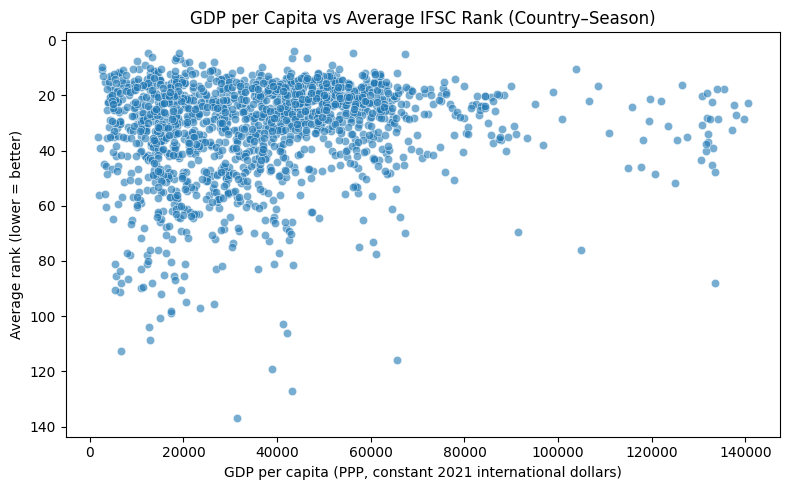

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=country_season,
                x='gdp_per_capita',
                y='mean_rank',
                alpha=0.6)

plt.gca().invert_yaxis()
plt.xlabel("GDP per capita (PPP, constant 2021 international dollars)")
plt.ylabel("Average rank (lower = better)")
plt.title("GDP per Capita vs Average IFSC Rank (Country–Season)")
plt.tight_layout()
plt.show()

Now, we are seeing that high GDP countries are clustered mostly between rank 15-35 and low GDP countries are spread much wider.

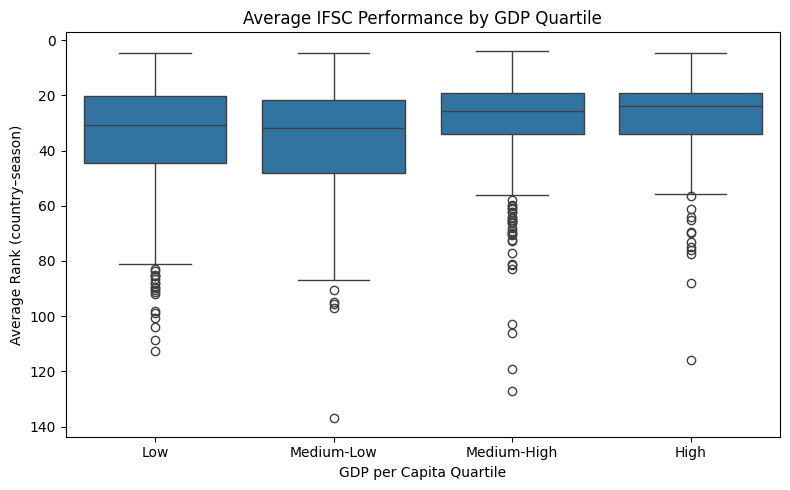

In [8]:
country_season['gdp_quartile'] = pd.qcut(
    country_season['gdp_per_capita'],
    4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

plt.figure(figsize=(8,5))
sns.boxplot(data=country_season, x='gdp_quartile', y='mean_rank')
plt.gca().invert_yaxis()
plt.xlabel("GDP per Capita Quartile")
plt.ylabel("Average Rank (country–season)")
plt.title("Average IFSC Performance by GDP Quartile")
plt.tight_layout()
plt.show()

Here we are checking the box plot. We see that low GDP quartile has wide spread and worse median while high GDP quartile has tighter spread and better median.

---
The plots are supporting my claim, now I'll start actually formally testing it.

In [9]:
corrcof = country_season[['gdp_per_capita','mean_rank']].corr()
r = corrcof.loc['gdp_per_capita', 'mean_rank']
print("Correlation coefficient r:", r)

Correlation coefficient r: -0.1360269195967164


The correlation coefficient is -0.136027. It is weak but it means that as GDP goes up, rank ,which is worse when larger, goes down

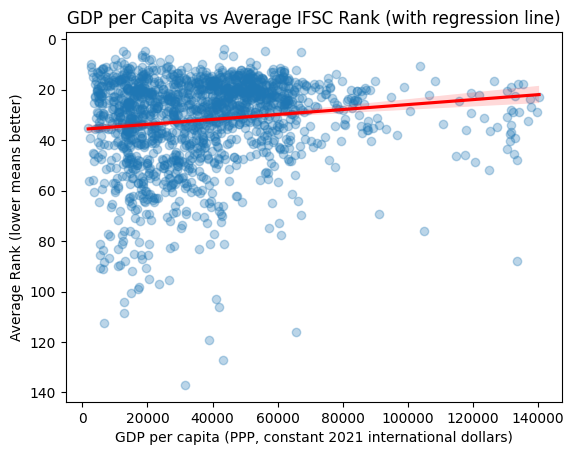

In [10]:
sns.regplot(
    data=country_season,
    x='gdp_per_capita',
    y='mean_rank',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.gca().invert_yaxis()  # because rank: lower = better
plt.title("GDP per Capita vs Average IFSC Rank (with regression line)")
plt.xlabel("GDP per capita (PPP, constant 2021 international dollars)")
plt.ylabel("Average Rank (lower means better)")
plt.show()

As GDP increases, the average rank number decreases in other words performance gets better so the regression line confirms exactly the same thing as with the correlation coefficient.

----

***HYPOTHESIS TESTING***
-----

**H0**(Null Hypothesis): There is no statistically significant relationship betweeen a country's GDP per capita and the ranking achieved by its athletes in IFSC competition.

 **H1**(Alternative Hypothesis): Athletes from countries with higher GDP per capita tend to achieve significantly better(lower) ranks in IFSC competitions across seasons.

I'll do 2 type of tests.

**1)Correlation test**

**2)Two-sample t-test**


------

**Test 1 - Pearson correlation**
----

*H0: p = 0*

There is no linear relationship between GDP per capita and average IFSC rank.



*H1: p != 0*

There is a linear relationship between GDP per capita and average IFSC rank.

In [11]:
from scipy.stats import pearsonr

x = country_season['gdp_per_capita']
y = country_season['mean_rank']

r, pearson_correlation = pearsonr(x, y)

print("Pearson's correlation:", r)
print("P value:", pearson_correlation)

Pearson's correlation: -0.13602691959671662
P value: 2.990356709326504e-08



Pearson's correlation test shows that r = -0.1360

and p-value = 2.99E-8
Because p<0.05, we reject the null hypothesis that there is no relationship between GDP per capita and average IFSC rank.

**Test 2 - Spearman's Rank Correlation**
-------

H0: s = 0

There is no monotonic relationship between a country’s GDP per capita and the average IFSC rank achieved by its athletes.

H1: s!= 0

There exists a monotonic relationship between a country’s GDP per capita and the average IFSC rank achieved by its athletes.

In [12]:
from scipy.stats import spearmanr

x = country_season['gdp_per_capita']
y = country_season['mean_rank']

rho, spearman_correlation = spearmanr(x, y)

print("Spearman's correlation:", rho)
print("P value:", spearman_correlation)

Spearman's correlation: -0.14578292755926042
P value: 2.7877510093214044e-09


So even without assuming a straight line(because Pearson's coefficient measured linear relationship), countries with higher GDP per capita still tend to have better (lower) average IFSC ranks.

**Test 3 - Two sampled t-test for High vs Low GDP countries**
-------

H0: Mean of the low GDP=Mean of the high GDP

The mean average rank is the same for low GDP and high GDP country seasons.

H1: Mean of the low GDP>Mean of the high GDP

Low GDP country-seasons have worse (higher) average ranks than high-GDP ones.


In [13]:
from scipy.stats import ttest_ind
# We define low and high GDP groups using the 1st and 3rd quartiles
quartile1 = country_season['gdp_per_capita'].quantile(0.25)
quartile3 = country_season['gdp_per_capita'].quantile(0.75)

low_gdp = country_season[country_season['gdp_per_capita'] <= quartile1]['mean_rank']
high_gdp = country_season[country_season['gdp_per_capita'] >= quartile3]['mean_rank']

print("Low GDP group size:", len(low_gdp))
print("High GDP group size:", len(high_gdp))

t_statistic, p_twotailed = ttest_ind(low_gdp, high_gdp, equal_var=False)

print("Low GDP mean rank:", low_gdp.mean())
print("High GDP mean rank:", high_gdp.mean())
print("T statistic:", t_statistic)

if low_gdp.mean() > high_gdp.mean():
    p_onetailed = p_twotailed / 2
else:
    p_onetailed = 1 - p_twotailed / 2

print("One-sided p value:", p_onetailed)

Low GDP group size: 412
High GDP group size: 412
Low GDP mean rank: 35.36112593235769
High GDP mean rank: 27.79879552821249
T statistic: 6.388193668415048
One-sided p value: 1.5311673762201798e-10



To test whether economic wealth is associated with climbing performance, I conducted a Welch two-sample t-test and compared the average IFSC rankings of countries in the lowest and highest GDP per capita quartiles. The low GDP group had a mean rank of 35.36, while the high GDP group had a mean rank of 27.80, indicating better average performance for countries with higher GDP.

 The test gave us a t-statistic of 6.39 and a one-sided p-value of 1.53E-10 . Since this p-value<0.05, the null hypothesis was rejected. This provides strong evidence that athletes from higher-GDP countries tend to achieve significantly better rankings in IFSC competitions.

**A Subgroup Analysis: Male vs Female pattern comparison**
-------

--------




In [14]:
male_df = df[df['gender'] == 'male']
female_df = df[df['gender'] == 'female']

print("Male count:", male_df.shape)
print("Female count:", female_df.shape)

Male count: (72425, 18)
Female count: (54016, 18)


In [15]:
male_country_season = (
    male_df.groupby(['country', 'season'], as_index=False)
    .agg(
        mean_rank=('rank', 'mean'),
        gdp_per_capita=('gdp_per_capita', 'mean')
    )
)

female_country_season = (
    female_df.groupby(['country', 'season'], as_index=False)
    .agg(
        mean_rank=('rank', 'mean'),
        gdp_per_capita=('gdp_per_capita', 'mean')
    )
)

print(male_country_season.shape, female_country_season.shape)

(1608, 4) (1427, 4)


In [16]:
from scipy.stats import pearsonr


r_male, p_male = pearsonr(
    male_country_season['gdp_per_capita'],
    male_country_season['mean_rank']
)


r_female, p_female = pearsonr(
    female_country_season['gdp_per_capita'],
    female_country_season['mean_rank']
)

print("MALE: r =", r_male, " | p =", p_male)
print("FEMALE: r =", r_female, " | p =", p_female)

MALE: r = -0.13855753517930275  | p = 2.4225652532713876e-08
FEMALE: r = -0.0750262412988366  | p = 0.004572839024605347


In [17]:
from scipy.stats import spearmanr

spearman_male, p_male_spearman = spearmanr(
    male_country_season['gdp_per_capita'],
    male_country_season['mean_rank']
)

spearman_female, p_female_spearman = spearmanr(
    female_country_season['gdp_per_capita'],
    female_country_season['mean_rank']
)

print("MALE Spearman:", spearman_male, " | p =", p_male_spearman)
print("FEMALE Spearman:", spearman_female, " | p =", p_female_spearman)

MALE Spearman: -0.14781032095693766  | p = 2.595866569448317e-09
FEMALE Spearman: -0.04781454664033043  | p = 0.070969007498928


For Male athletes:
------
Pearson= -0.139

p-value= 2.42 x 10E-8 which is highly significant


Spearman = -0.148

p-value ≈ 2.59 × 10E-9 which ishighly significant

For male athletes, a weak but statistically significant negative relationship was found between a country’s GDP per capita and average IFSC ranking.Both the Pearson and Spearman correlations are statistically significant, indicating that this relationship is unlikely to be due to random chance.

For Female athletes:
-
Pearson= -0.075

p-value ≈ 0.0046 which is significant

Spearman = -0.047

p-value ≈ 0.0709 which is not significant for α = 0.05

For female athletes, the relationship between GDP per capita and average ranking was weaker and less consistent than in the male subgroup. While the Pearson correlation indicated a small negative relationship, the Spearman correlation was not statistically significant at the 0.05 level.

This suggests that for female climbers, economic conditions at the country level may play a smaller or more complex role, and other factors such as training programs, and representation in the sport may be more influential than national wealth alone.

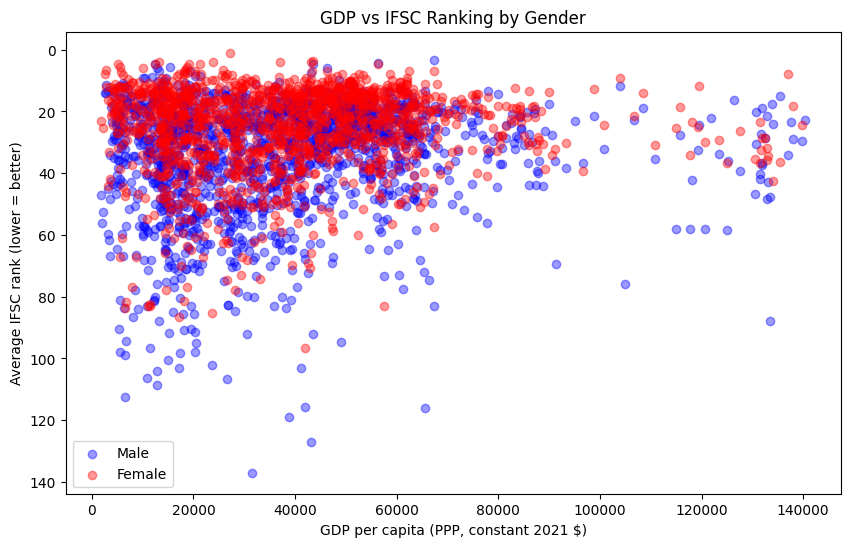

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    male_country_season['gdp_per_capita'],
    male_country_season['mean_rank'],
    alpha=0.4,
    label='Male',
    color='blue'
)

plt.scatter(
    female_country_season['gdp_per_capita'],
    female_country_season['mean_rank'],
    alpha=0.4,
    label='Female',
    color='red'
)

plt.gca().invert_yaxis()
plt.xlabel("GDP per capita (PPP, constant 2021 $)")
plt.ylabel("Average IFSC rank (lower = better)")
plt.title("GDP vs IFSC Ranking by Gender")
plt.legend()

plt.show()

Female performance appears more widely distributed across all GDP levels, indicating that strong female performance emerges from both high and low GDP countries.
Our conclusion is when separated by gender, the hypothesis is more strongly supported in male athletes than in female athletes.

While higher GDP is associated with slightly better rankings for both groups, the relationship is weak overall and only consistently significant in the male subgroup.